Found 1 face(s)


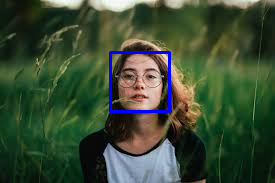

Processing complete. Look for bounding boxes on the image above.


In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

# Load pre-trained Haar cascade classifiers for face and smile detection
# These XML files should be available (e.g., in the OpenCV data directory or downloaded)
# For Colab, you might need to upload them or fetch them from a URL.
# You can find them in the OpenCV GitHub repository:
# face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
# smile_cascade = cv2.CascadeClassifier(cv2.data.haascades + 'haarcascade_smile.xml')

# As a workaround for Colab without direct access to cv2.data.haascades:
# Download these files if you don't have them locally or upload them to your Colab environment.
# For demonstration, let's assume they are in the current directory or provide a path.
# You can download them from:
# https://github.com/opencv/opencv/blob/4.x/data/haarcascades/haarcascade_frontalface_default.xml
# https://github.com/opencv/opencv/blob/4.x/data/haarcascades/haarcascade_smile.xml

# Placeholder paths - replace with actual paths if you download them
# For simplicity, I'll use common Colab download approach if not present.
import os

face_cascade_path = 'haarcascade_frontalface_default.xml'
smile_cascade_path = 'haarcascade_smile.xml'

# Download if not present
if not os.path.exists(face_cascade_path):
    !wget -q https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml
if not os.path.exists(smile_cascade_path):
    !wget -q https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_smile.xml

face_cascade = cv2.CascadeClassifier(face_cascade_path)
smile_cascade = cv2.CascadeClassifier(smile_cascade_path)

# Load an image
# Using the image uploaded by the user
image_path = 'human.jfif' # Using the user's uploaded image

img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file integrity.")
else:
    # Convert image to grayscale for cascade detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    # The parameters are tuned for general use; you might need to adjust them.
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    print(f"Found {len(faces)} face(s)")

    # Draw rectangles around the faces and detect smiles within each face
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2) # Blue rectangle for face

        roi_gray = gray[y:y + h, x:x + w]
        roi_color = img[y:y + h, x:x + w]

        # Detect smiles within the region of interest (face)
        # Parameters for smile detection are often more sensitive
        smiles = smile_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.7, # Higher scaleFactor for smiles
            minNeighbors=20, # More neighbors to reduce false positives
            minSize=(25, 25), # Minimum size of a smile
            flags=cv2.CASCADE_SCALE_IMAGE
        )

        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 255, 0), 2) # Green rectangle for smile
            print("  Smile detected!")

    # Display the output image in Colab
    cv2_imshow(img)

    # Optionally, save the output image
    # cv2.imwrite('detected_smiles.jpg', img)

    print("Processing complete. Look for bounding boxes on the image above.")
